🎟️ Final Ticket Winners:
            name allocation_type  fan_score  predicted_prob  trivia_score
83    Student_83   Digital Queue   0.667364        0.942965            53
142  Student_142   Digital Queue   0.684231        0.917278            49
0      Student_0   Digital Queue   0.554784        0.524516            89
61    Student_61   Digital Queue   0.500823        0.543043            68
26    Student_26   Digital Queue   0.411129        0.204131            49
16    Student_16   Digital Queue   0.659248        0.865420            94
35    Student_35   Digital Queue   0.635064        0.776926            41
70    Student_70   Digital Queue   0.734178        0.952376            67
80    Student_80   Digital Queue   0.517273        0.227052            85
107  Student_107   Digital Queue   0.617941        0.698212            86
85    Student_85   Digital Queue   0.451342        0.116895            84
134  Student_134   Digital Queue   0.621498        0.535900            77
39    Student

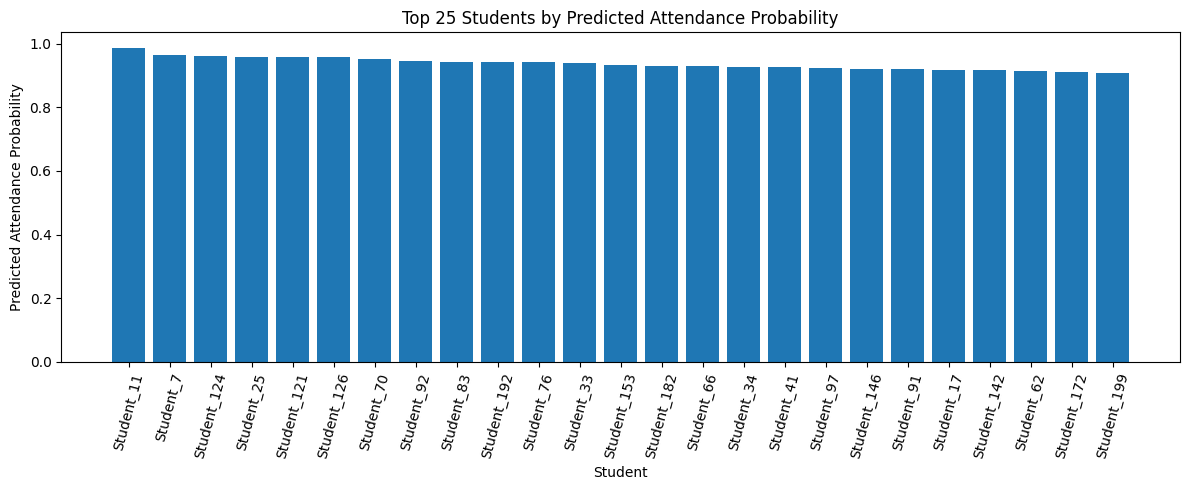

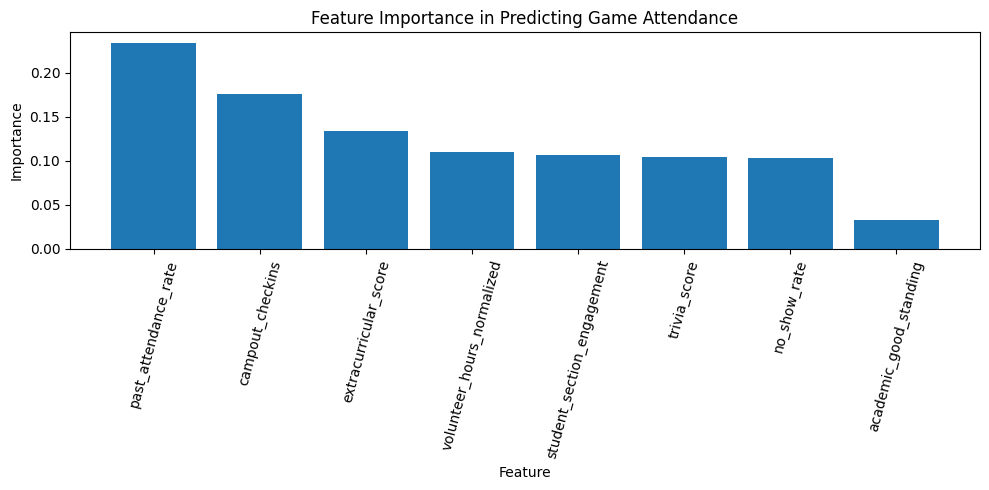

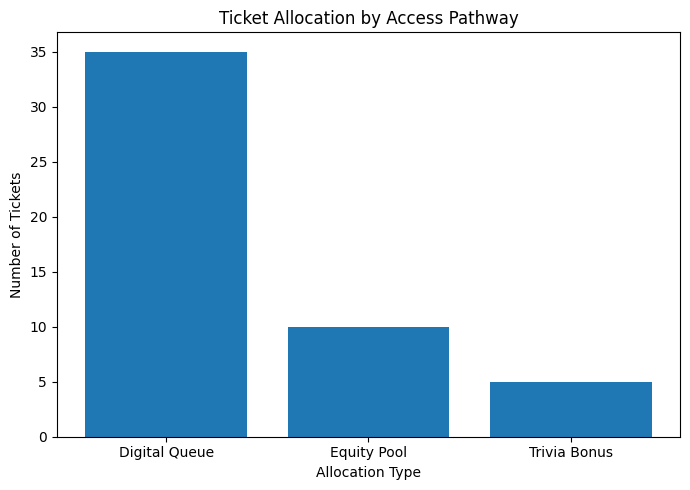

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import MinMaxScaler


# =========================
# CREATE SAMPLE STUDENT DATA
# =========================

np.random.seed(42)

n = 200

students = pd.DataFrame({
    "name": [f"Student_{i}" for i in range(n)],

    # Attendance reliability
    "past_attendance_rate": np.random.uniform(0.4, 1.0, n),
    "no_show_rate": np.random.uniform(0.0, 0.3, n),

    # Campout tradition
    "campout_checkins": np.random.randint(0, 20, n),
    "trivia_score": np.random.randint(40, 100, n),

    # Expanded access features
    "extracurricular_score": np.random.randint(0, 100, n),
    "volunteer_hours": np.random.randint(0, 80, n),
    "academic_good_standing": np.random.randint(0, 2, n),

    # Duke basketball engagement
    "student_section_engagement": np.random.randint(0, 100, n)
})


# =========================
# NORMALIZE FEATURES
# =========================

students["campout_score"] = students["campout_checkins"] / students["campout_checkins"].max()
students["trivia_score_normalized"] = students["trivia_score"] / 100
students["extracurricular_score_normalized"] = students["extracurricular_score"] / 100
students["volunteer_hours_normalized"] = students["volunteer_hours"] / students["volunteer_hours"].max()
students["student_section_engagement_normalized"] = students["student_section_engagement"] / 100


# =========================
# TRANSPARENT FAN SCORE
# =========================

students["fan_score"] = (
    0.35 * students["past_attendance_rate"] +
    0.20 * students["campout_score"] +
    0.15 * students["trivia_score_normalized"] +
    0.10 * students["student_section_engagement_normalized"] +
    0.10 * students["extracurricular_score_normalized"] +
    0.05 * students["volunteer_hours_normalized"] +
    0.05 * students["academic_good_standing"] -
    0.15 * students["no_show_rate"]
)


# =========================
# SIMULATE ACTUAL ATTENDANCE
# =========================

students["actual_show"] = (
    students["fan_score"] + np.random.normal(0, 0.08, n)
) > 0.55

students["actual_show"] = students["actual_show"].astype(int)


# =========================
# TRAIN MODEL
# =========================

features = [
    "past_attendance_rate",
    "no_show_rate",
    "campout_checkins",
    "trivia_score",
    "extracurricular_score",
    "volunteer_hours_normalized",
    "academic_good_standing",
    "student_section_engagement"
]

X = students[features]
y = students["actual_show"]

model = LogisticRegression(max_iter=1000)
model.fit(X, y)

students["predicted_prob"] = model.predict_proba(X)[:, 1]


# =========================
# HYBRID TICKET ALLOCATION
# =========================

TOTAL_TICKETS = 100

campout_tickets = 50
digital_queue_tickets = 35
equity_pool_tickets = 10
trivia_bonus_tickets = 5


# =========================
# DIGITAL QUEUE WINNERS
# =========================

digital_weights = students["predicted_prob"] / students["predicted_prob"].sum()

digital_winners = students.sample(
    n=digital_queue_tickets,
    weights=digital_weights,
    random_state=1
)


# =========================
# TRIVIA BONUS WINNERS
# =========================

remaining_after_digital = students[
    ~students["name"].isin(digital_winners["name"])
]

trivia_bonus_winners = remaining_after_digital.sort_values(
    by="trivia_score",
    ascending=False
).head(trivia_bonus_tickets)


# =========================
# EQUITY POOL SIMULATION
# =========================

remaining_after_trivia = remaining_after_digital[
    ~remaining_after_digital["name"].isin(trivia_bonus_winners["name"])
]

equity_pool_winners = remaining_after_trivia.sample(
    n=equity_pool_tickets,
    random_state=2
)


# =========================
# FINAL WINNER LIST
# =========================

digital_winners["allocation_type"] = "Digital Queue"
trivia_bonus_winners["allocation_type"] = "Trivia Bonus"
equity_pool_winners["allocation_type"] = "Equity Pool"

final_winners = pd.concat([
    digital_winners,
    trivia_bonus_winners,
    equity_pool_winners
])

print("🎟️ Final Ticket Winners:")
print(final_winners[[
    "name",
    "allocation_type",
    "fan_score",
    "predicted_prob",
    "trivia_score"
]])


# =========================
# SIMULATE SHOW-UP RESULTS
# =========================

final_winners["show_up"] = (
    np.random.rand(len(final_winners)) < final_winners["predicted_prob"]
)

no_shows = final_winners[final_winners["show_up"] == False]

print("\n❌ No-shows:")
print(no_shows[["name", "allocation_type", "predicted_prob"]])


# =========================
# RANDOM LOTTERY BASELINE
# =========================

random_winners = students.sample(
    n=len(final_winners),
    random_state=1
)

random_winners["show_up"] = (
    np.random.rand(len(random_winners)) < random_winners["predicted_prob"]
)

random_no_shows = random_winners[random_winners["show_up"] == False]

print("\n📊 Comparison:")
print("🎲 Random Lottery No-Shows:", len(random_no_shows))
print("🤖 AI-Assisted Allocation No-Shows:", len(no_shows))


# =========================
# REALLOCATE NO-SHOW TICKETS
# =========================

remaining_students = students[
    ~students["name"].isin(final_winners["name"])
]

reallocation_weights = (
    remaining_students["predicted_prob"] /
    remaining_students["predicted_prob"].sum()
)

reallocated_winners = remaining_students.sample(
    n=len(no_shows),
    weights=reallocation_weights,
    random_state=3
)

print("\n🔁 Reallocated Tickets:")
print(reallocated_winners[["name", "predicted_prob"]])


# =========================
# VISUALIZATION 1: PREDICTED ATTENDANCE
# =========================

top_students = students.sort_values(
    by="predicted_prob",
    ascending=False
).head(25)

plt.figure(figsize=(12, 5))
plt.bar(top_students["name"], top_students["predicted_prob"])
plt.title("Top 25 Students by Predicted Attendance Probability")
plt.xlabel("Student")
plt.ylabel("Predicted Attendance Probability")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()


# =========================
# VISUALIZATION 2: FEATURE IMPORTANCE
# =========================

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X, y)

feature_importance = pd.DataFrame({
    "feature": features,
    "importance": rf_model.feature_importances_
}).sort_values(by="importance", ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(feature_importance["feature"], feature_importance["importance"])
plt.title("Feature Importance in Predicting Game Attendance")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()


# =========================
# VISUALIZATION 3: ALLOCATION BREAKDOWN
# =========================

allocation_counts = final_winners["allocation_type"].value_counts()

plt.figure(figsize=(7, 5))
plt.bar(allocation_counts.index, allocation_counts.values)
plt.title("Ticket Allocation by Access Pathway")
plt.xlabel("Allocation Type")
plt.ylabel("Number of Tickets")
plt.tight_layout()
plt.show()